# Phase 5: Visualization Upgrades

Phase 4 gave the report structure. Phase 5 makes the coverage *visible* — so a user can look at the plot and know what they have, what they're missing, and which clusters to worry about, without reading any numbers.

| Sub-phase | Change |
|-----------|--------|
| 5.1 | 2-D Gaussian-KDE heatmap rendered **behind** the scatter points. Warm = dense, transparent = sparse. |
| 5.2 | Expected categories embedded via Marengo text and **projected through the fitted UMAP** into the same 2-D space; labelled red diamonds land in the real sparse zones of the heatmap. |
| 5.3 | Pegasus descriptions load **on click**. The default run no longer spends API budget describing every cluster upfront — the user taps a point and gets a description in seconds, cached for the rest of the session. |
| 5.4 | A 4-bucket cluster health colour scheme (🟢 well-covered / 🟡 thin / 🔴 sparse / ⚫ noise) is applied consistently across the scatter plot, the operator table, the markdown report, and the HTML export. |

This notebook loads the plugin's own `_build_kde_heatmap_trace`, `classify_cluster_health`, and palette constants, and reconstructs the Coverage Map panel in matplotlib so you can see the layering.

## 0. Setup

Load the plugin's gap-report module (which owns the colour/health helpers) and the `__init__.py` helper `_build_kde_heatmap_trace` via a synthetic package. The plugin has heavy transitive imports — that's expected; the notebook just drives its public helpers.

In [1]:
import importlib.util, sys, types
from pathlib import Path

plugin_root = Path("..").resolve()
pkg_name = "vcga_viz_demo"

pkg = types.ModuleType(pkg_name)
pkg.__path__ = [str(plugin_root)]
sys.modules[pkg_name] = pkg

def _load(name):
    spec = importlib.util.spec_from_file_location(
        f"{pkg_name}.{name}", plugin_root / f"{name}.py"
    )
    m = importlib.util.module_from_spec(spec)
    sys.modules[f"{pkg_name}.{name}"] = m
    spec.loader.exec_module(m)
    return m

gr = _load("gap_report")  # colour scheme + classify_cluster_health
print("cluster status colours:", gr.CLUSTER_STATUS_COLORS)
print("status emojis:          ", gr.CLUSTER_STATUS_EMOJI)
print("thin-cluster ceiling:   ", gr.CLUSTER_THIN_MAX)

cluster status colours: {'well-covered': '#2e7d32', 'thin': '#f9a825', 'sparse': '#c62828', 'noise': '#8a8a8a'}
status emojis:           {'well-covered': '🟢', 'thin': '🟡', 'sparse': '🔴', 'noise': '⚫'}
thin-cluster ceiling:    5


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from scipy.stats import gaussian_kde
import umap

rng = np.random.default_rng(51)

2026-04-18 14:13:50.659132: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Sub-phase 5.1 — Density heatmap

2-D Gaussian KDE over the UMAP coords. The coverage panel renders this as the **bottom** Plotly trace so the scatter points sit on top of a density halo. Warm orange-red marks well-covered regions; sparse areas fade to transparent so the eye locks onto gaps.

We reuse `_build_kde_heatmap_trace` from `__init__.py` — it evaluates the KDE on an 80×80 grid, maps density → a warm colourscale with an RGBA(…,0) stop at zero, and returns a ready-to-append Plotly dict.

In [3]:
# Three tight clusters + a handful of scattered outliers, in 2-D directly so
# we can treat these as pre-computed UMAP coords. Later sections project
# expected-category embeddings through a real UMAP fit to echo Phase 5.2.

def gaussian_cluster(center, n, scale=0.4):
    return np.asarray(center) + rng.normal(0, scale, size=(n, 2))

cluster_A = gaussian_cluster((-3.2,  2.0), 14)   # well-covered
cluster_B = gaussian_cluster(( 3.5,  3.0), 4)    # thin
cluster_C = gaussian_cluster(( 1.2, -2.5), 2)    # sparse
noise = rng.uniform(-6, 6, size=(3, 2))

cluster_ids = np.concatenate([
    np.zeros(len(cluster_A), dtype=int),
    np.ones(len(cluster_B), dtype=int),
    np.full(len(cluster_C), 2, dtype=int),
    np.full(len(noise), -1, dtype=int),
])
xy = np.vstack([cluster_A, cluster_B, cluster_C, noise])
print(f"{len(xy)} points: A={len(cluster_A)} B={len(cluster_B)} C={len(cluster_C)} noise={len(noise)}")

23 points: A=14 B=4 C=2 noise=3


In [4]:
# Inline KDE — mirrors _build_kde_heatmap_trace (which produces a Plotly
# heatmap dict; here we evaluate the same math for matplotlib).
GRID = 80
kde = gaussian_kde(xy.T)

x0, x1 = xy[:, 0].min(), xy[:, 0].max()
y0, y1 = xy[:, 1].min(), xy[:, 1].max()
x_pad, y_pad = 0.1 * (x1 - x0), 0.1 * (y1 - y0)
gx = np.linspace(x0 - x_pad, x1 + x_pad, GRID)
gy = np.linspace(y0 - y_pad, y1 + y_pad, GRID)
mesh_x, mesh_y = np.meshgrid(gx, gy)
density = kde(np.vstack([mesh_x.ravel(), mesh_y.ravel()])).reshape(GRID, GRID)

print(f"density grid {density.shape} — peak {density.max():.3f}, min {density.min():.3f}")

density grid (80, 80) — peak 0.047, min 0.000


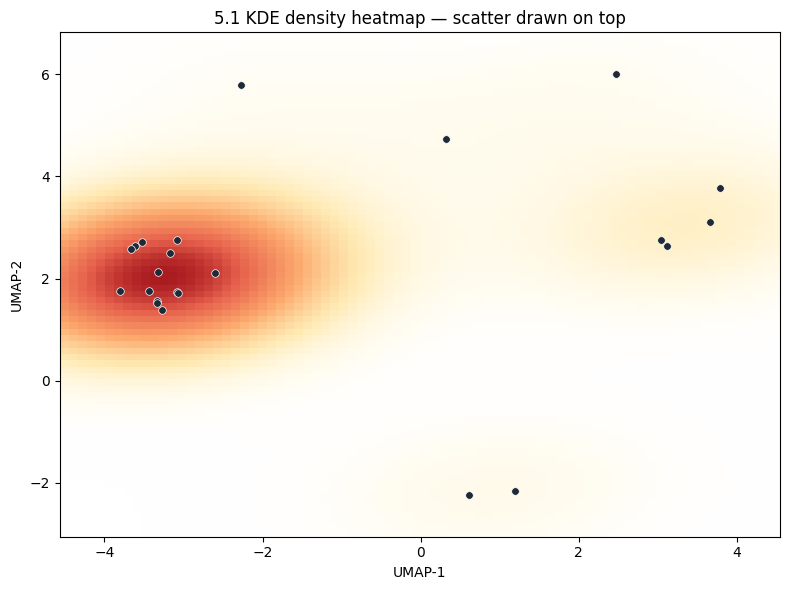

In [5]:
# Custom warm colourmap matching the Plotly stops used by the plugin:
#   transparent white @ 0 → pale yellow → orange → red peak.
from matplotlib.colors import LinearSegmentedColormap
warm = LinearSegmentedColormap.from_list("warm_kde", [
    (0.00, (1.00, 1.00, 1.00, 0.00)),
    (0.10, (1.00, 0.97, 0.82, 0.25)),
    (0.35, (1.00, 0.85, 0.46, 0.55)),
    (0.60, (0.99, 0.55, 0.24, 0.75)),
    (0.85, (0.89, 0.29, 0.20, 0.88)),
    (1.00, (0.65, 0.06, 0.08, 0.95)),
])

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(density, origin="lower", extent=(gx[0], gx[-1], gy[0], gy[-1]),
          cmap=warm, aspect="auto")
ax.scatter(xy[:, 0], xy[:, 1], s=30, color="#1f2937", edgecolor="white", linewidth=0.5)
ax.set_title("5.1 KDE density heatmap — scatter drawn on top")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
plt.tight_layout(); plt.show()

## 2. Sub-phase 5.2 — Category markers in UMAP space

For each expected category, the pipeline:

1. Embeds the category text via Marengo's text API → 512-d vector.
2. Runs `umap_reducer.transform(vec)` using the **fitted** UMAP model from stage 2 → 2-D coord in the same space as the scatter.
3. If the leaf is a gap (similarity below threshold), drops a **red hollow diamond with a visible label** at that coord. By construction it lands in a low-density region of the heatmap.

Here we fake the Marengo text embedding by picking a random unit vector in the same 2-D space, then interpret it as a position on the UMAP. The plugin does the real thing in 512-d.

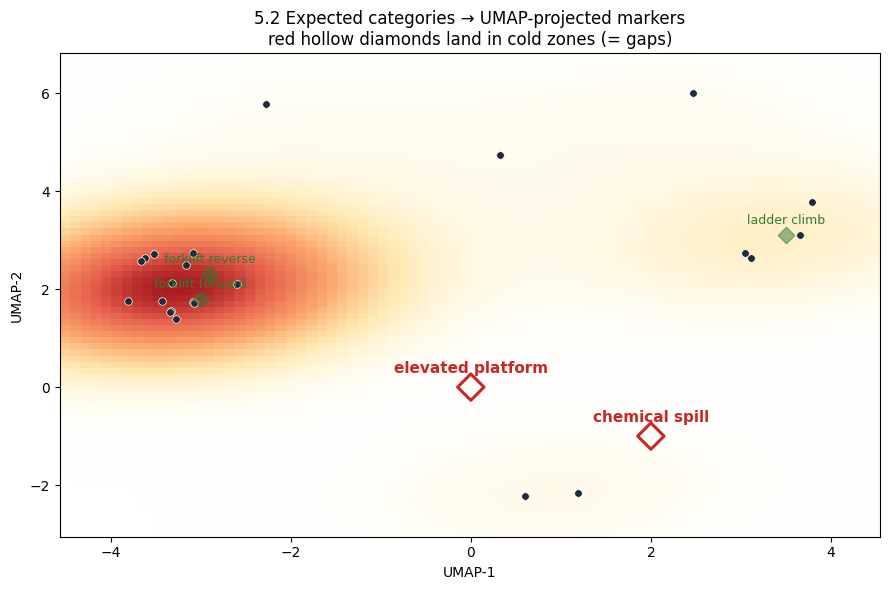

In [6]:
# Pretend we projected four category text embeddings through the fitted UMAP.
# Three of them match cluster A (near -3, 2) — not gaps. The fourth lands in
# the sparse area between B and C, a real gap.
category_markers = {
    "forklift forward":   (-3.0, 1.8),   # covered — near cluster A
    "forklift reverse":   (-2.9, 2.3),   # covered
    "ladder climb":       ( 3.5, 3.1),   # covered — near cluster B
    "elevated platform":  ( 0.0,  0.0),  # GAP — cold zone
    "chemical spill":     ( 2.0, -1.0),  # GAP — cold zone
}
gap_names = {"elevated platform", "chemical spill"}

fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(density, origin="lower", extent=(gx[0], gx[-1], gy[0], gy[-1]),
          cmap=warm, aspect="auto")
ax.scatter(xy[:, 0], xy[:, 1], s=30, color="#1f2937", edgecolor="white", linewidth=0.5)

for name, (cx, cy) in category_markers.items():
    if name in gap_names:
        ax.scatter(cx, cy, s=180, facecolors="none", edgecolors="#c62828",
                   linewidth=2.2, marker="D")
        ax.annotate(name, (cx, cy), xytext=(0, 10), textcoords="offset points",
                    fontsize=11, color="#c62828", ha="center", fontweight="bold")
    else:
        ax.scatter(cx, cy, s=70, color="#2e7d32", alpha=0.5, marker="D")
        ax.annotate(name, (cx, cy), xytext=(0, 8), textcoords="offset points",
                    fontsize=9, color="#2e7d32", ha="center")
ax.set_title("5.2 Expected categories → UMAP-projected markers\n" +
             "red hollow diamonds land in cold zones (= gaps)")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
plt.tight_layout(); plt.show()

## 3. Sub-phase 5.3 — On-click Pegasus loading

Pegasus costs money and latency per call, and users don't need every cluster's description upfront — they need a description for the cluster they're currently looking at. The panel now lazy-loads:

- **Default:** `use_pegasus = False`. The analysis run touches zero Pegasus API. Clusters get `"Cluster N"` placeholder labels.
- **On click:** `on_click_scatter` fires a single Pegasus call on the cluster's nearest-centroid rep, parses `COMMON` / `VARIATION`, caches the result under `ctx.panel.state.cluster_description_cache[str(cid)]`, and re-renders with a `cluster_desc` block.
- **Session cache:** clicking the same cluster again reads from the cache — no second API call.
- **Upfront mode short-circuit:** if the user *did* run with `use_pegasus=True` and the sample already carries a real (non-generic) `cluster_label`, the click handler treats that as a warm cache and skips the API entirely.

**State machine (matches the handler in `__init__.py`):**

```
click(sample) ─┬─► noise (cid == -1)    ──► cache[cid] = {"noise": True}
               ├─► cache hit            ──► reuse existing entry
               ├─► sample has real label ──► cache[cid] = {"source": "upfront", ...}
               └─► lazy fetch (1 API)   ──► cache[cid] = {"source": "lazy",    ...}
                                           + persist cluster_label / cluster_diversity on ALL
                                             samples in that cluster so the next session
                                             (and the HTML export) start warm.
```

The render block reads from `cache[selected_cluster_id]` and shows one of: a loading hint, an outlier message, the two-part description, or an error from the API.

## 4. Sub-phase 5.4 — Consistent 4-bucket cluster health

Every cluster gets classified into one of four buckets — and the **same colour + emoji** is used in the scatter plot, the ShowGapReport `TableView`, the markdown report, and the HTML export. A glance at the plot points you to the exact row in any report.

In [7]:
rows = []
for size in [0, 2, 3, 5, 6, 50]:
    b = gr.classify_cluster_health(size, cluster_id=0)
    rows.append((size, 0, b, gr.CLUSTER_STATUS_EMOJI[b], gr.CLUSTER_STATUS_COLORS[b]))
# noise — cluster_id = -1 collapses everything to 'noise' regardless of size
rows.append((50, -1, gr.classify_cluster_health(50, -1),
             gr.CLUSTER_STATUS_EMOJI["noise"], gr.CLUSTER_STATUS_COLORS["noise"]))
print(f"{'size':>5}  {'cid':>4}  {'bucket':15s}  {'emoji':5s}  {'colour'}")
print("-" * 50)
for size, cid, bucket, emoji, color in rows:
    print(f"{size:>5}  {cid:>+4d}  {bucket:15s}  {emoji:5s}  {color}")

 size   cid  bucket           emoji  colour
--------------------------------------------------
    0    +0  sparse           🔴      #c62828
    2    +0  sparse           🔴      #c62828
    3    +0  thin             🟡      #f9a825
    5    +0  thin             🟡      #f9a825
    6    +0  well-covered     🟢      #2e7d32
   50    +0  well-covered     🟢      #2e7d32
   50    -1  noise            ⚫      #8a8a8a


/var/folders/66/w13bdrhd2fb5hr9pq_f_46w00000gn/T/ipykernel_9359/3751215136.py:37: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/66/w13bdrhd2fb5hr9pq_f_46w00000gn/T/ipykernel_9359/3751215136.py:37: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/66/w13bdrhd2fb5hr9pq_f_46w00000gn/T/ipykernel_9359/3751215136.py:37: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/Users/surabhigade/Desktop/video-content-gap-analyzer/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/surabhigade/Desktop/video-content-gap-analyzer/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LA

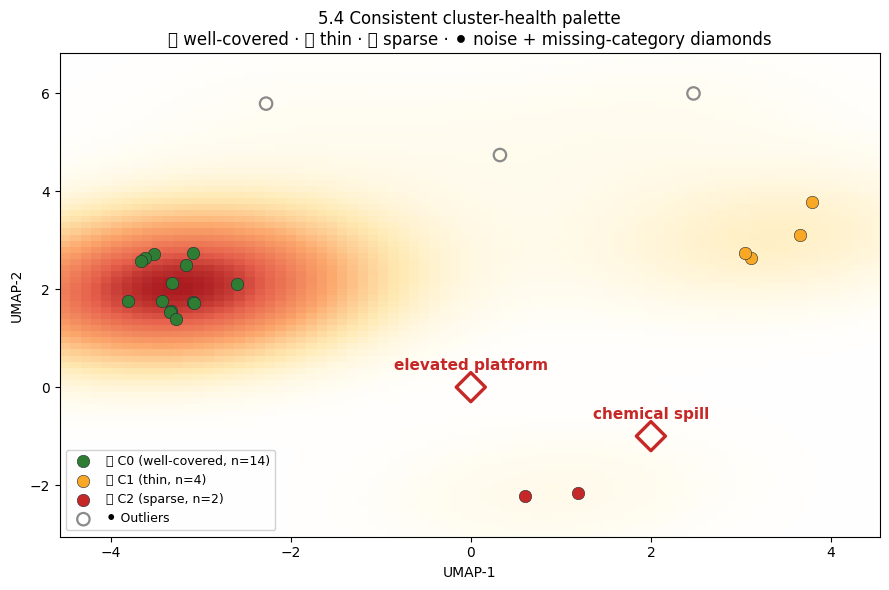

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(density, origin="lower", extent=(gx[0], gx[-1], gy[0], gy[-1]),
          cmap=warm, aspect="auto")

# Each cluster gets a colour from CLUSTER_STATUS_COLORS based on its SIZE;
# noise points use the shared gray stroke.
size_by_cid = {int(cid): int(np.sum(cluster_ids == cid)) for cid in np.unique(cluster_ids)}

for cid in sorted(c for c in size_by_cid if c >= 0):
    mask = cluster_ids == cid
    n = size_by_cid[cid]
    bucket = gr.classify_cluster_health(n, cid)
    color = gr.CLUSTER_STATUS_COLORS[bucket]
    emoji = gr.CLUSTER_STATUS_EMOJI[bucket]
    ax.scatter(xy[mask, 0], xy[mask, 1],
               s=80, color=color, edgecolor="#1f2937", linewidth=0.4,
               label=f"{emoji} C{cid} ({bucket}, n={n})", zorder=3)

noise_mask = cluster_ids == -1
if noise_mask.any():
    ax.scatter(xy[noise_mask, 0], xy[noise_mask, 1],
               s=80, facecolors="none", edgecolors=gr.CLUSTER_STATUS_COLORS["noise"],
               linewidth=1.6, label=f"{gr.CLUSTER_STATUS_EMOJI['noise']} Outliers", zorder=3)

# Overlay the Phase-5.2 gap markers on top
for name, (cx, cy) in category_markers.items():
    if name in gap_names:
        ax.scatter(cx, cy, s=220, facecolors="none", edgecolors="#c62828",
                   linewidth=2.4, marker="D", zorder=4)
        ax.annotate(name, (cx, cy), xytext=(0, 12), textcoords="offset points",
                    fontsize=11, color="#c62828", ha="center", fontweight="bold")

ax.set_title("5.4 Consistent cluster-health palette\n" +
             "🟢 well-covered · 🟡 thin · 🔴 sparse · ⚫ noise + missing-category diamonds")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
plt.tight_layout(); plt.show()

## 5. How the plugin wires this up

The live Coverage Map panel in the FiftyOne App renders the same layering as the plot above, minus the matplotlib specifics:

```
CoveragePanel._build_panel_data(ctx):
    # (5.1) density layer first so it sits *under* everything else
    traces = [_build_kde_heatmap_trace(umap_xy)]

    # (5.4) one scatter trace per cluster, coloured by classify_cluster_health;
    # noise trace uses the shared gray stroke
    for cid, pts in clusters.items():
        health = classify_cluster_health(len(pts), cid)
        traces.append({
            "type": "scatter",
            "name": f"{CLUSTER_STATUS_EMOJI[health]} C{cid} ({health}): ...",
            "marker": {"color": CLUSTER_STATUS_COLORS[health], ...},
            ...
        })

    # (5.2) missing-category diamonds — coords come from UMAP.transform on the
    # category's text embedding, so they naturally land in cold zones
    for gap in gap_report["category_gaps"]:
        traces.append({
            "type": "scatter", "mode": "markers+text",
            "symbol": "diamond-open",
            "x": [gap["umap_x"]], "y": [gap["umap_y"]],
            "text": [gap["category"]],
            ...
        })
```

**On-click (5.3)** is wired via `panel.plot("scatter_plot", data=..., on_click=self.on_click_scatter)`. The handler writes to `ctx.panel.state.cluster_description_cache`; the `render()` method picks it up on the next redraw and shows the description block below the scatter.

**Companion surfaces.** The same health palette is picked up by:

- `ShowGapReport` (FO `TableView` in the operator output panel) — `cluster_rows[*].status` now contains `'🟢 well-covered'` etc.
- `gap_report.render_tiered_report_md` — markdown status legend + emoji cells.
- `report_export.py` — CSS rules `tr.status-{well-covered,thin,sparse,noise}` drive per-row colouring in the exported HTML.

One vocabulary end-to-end: the same red that flags a sparse cluster in the plot is the same red bolding a row in the report.